# Chess Game EDA

Exploratory analysis of the Lichess games dataset behind the two prediction tasks:

- **Task A — Outcome**: white / black / draw (pre-game features only).
- **Task B — Rating**: the game's average player rating.

Everything here reads the cleaned dataset produced by `src.data`. Run `python -m src.data` first if `data/processed/` is empty.

In [1]:
import sys; sys.path.append('..')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src.data import load_processed
from src import features as F

df = load_processed()
eng = F.engineer(df)
print(df.shape)
df.head()

(19112, 11)


,rated,turns,victory_status,winner,increment_code,white_rating,black_rating,moves,opening_eco,opening_name,opening_ply
0,False,13,outoftime,white,15+2,1500,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,True,16,resign,black,5+10,1322,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,True,61,mate,white,5+10,1496,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,True,61,mate,white,20+0,1439,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,True,95,mate,white,30+3,1523,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


## Schema & basic stats

In [2]:
df.dtypes

rated              bool
turns             int64
victory_status      str
winner              str
increment_code      str
white_rating      int64
black_rating      int64
moves               str
opening_eco         str
opening_name        str
opening_ply       int64
dtype: object

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rated,19112,2,True,15467,NaN,NaN,NaN,NaN,NaN,NaN,NaN
turns,19112.0,NaN,NaN,NaN,60.5169,33.486465,1.0,37.0,55.0,79.0,349.0
victory_status,19112,4,resign,10694,NaN,NaN,NaN,NaN,NaN,NaN,NaN
winner,19112,3,white,9545,NaN,NaN,NaN,NaN,NaN,NaN,NaN
increment_code,19112,400,10+0,7356,NaN,NaN,NaN,NaN,NaN,NaN,NaN
white_rating,19112.0,NaN,NaN,NaN,1597.33942,289.979131,784.0,1401.0,1567.0,1792.0,2700.0
black_rating,19112.0,NaN,NaN,NaN,1590.05023,290.448563,789.0,1394.0,1563.0,1785.0,2723.0
moves,19112,18920,e4 e5,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
opening_eco,19112,365,A00,948,NaN,NaN,NaN,NaN,NaN,NaN,NaN
opening_name,19112,1477,Sicilian Defense,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Task A target — outcome balance

White has a small edge; draws are rare (~5%), which is why the models almost never predict 'draw'.

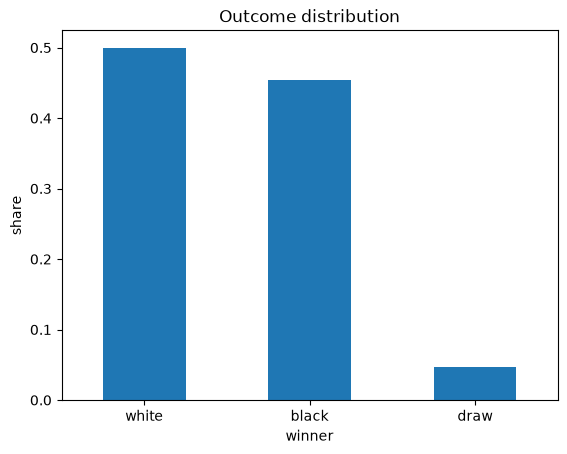

winner
white    0.499
black    0.454
draw     0.046
Name: proportion, dtype: float64

In [4]:
ax = df['winner'].value_counts(normalize=True).plot.bar(rot=0)
ax.set_ylabel('share'); ax.set_title('Outcome distribution'); plt.show()
df['winner'].value_counts(normalize=True).round(3)

## Task B target — average rating distribution

Roughly bell-shaped around ~1590; the spread is what the regressor must explain.

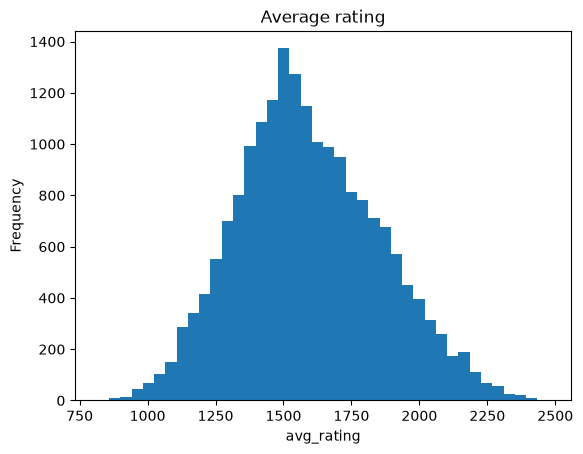

count    19112.0
mean      1593.7
std        262.5
min        816.5
25%       1409.5
50%       1570.0
75%       1772.5
max       2475.5
Name: avg_rating, dtype: float64

In [5]:
ax = eng['avg_rating'].plot.hist(bins=40)
ax.set_xlabel('avg_rating'); ax.set_title('Average rating'); plt.show()
eng['avg_rating'].describe().round(1)

## Ratings and rating difference

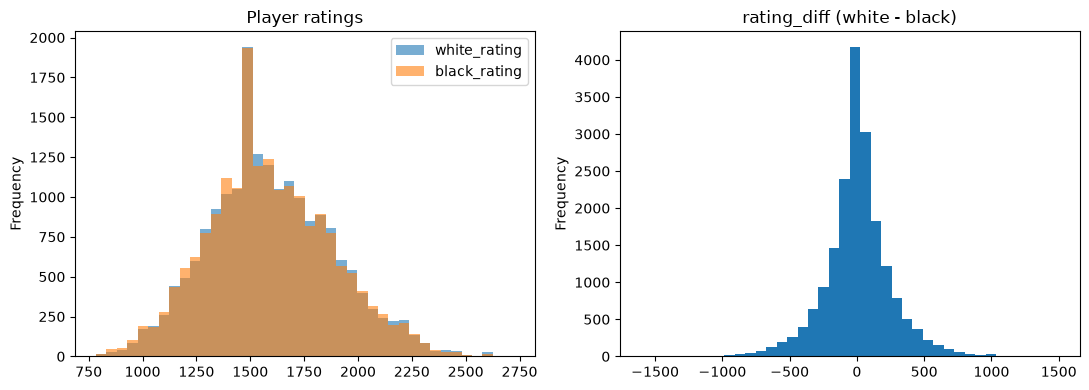

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df[['white_rating','black_rating']].plot.hist(bins=40, alpha=0.6, ax=axes[0])
axes[0].set_title('Player ratings')
eng['rating_diff'].plot.hist(bins=40, ax=axes[1])
axes[1].set_title('rating_diff (white - black)')
plt.tight_layout(); plt.show()

## Time-control buckets

Estimated duration = base + 40·increment (Lichess' formula). This dataset is dominated by `10+0` (rapid); true bullet/blitz games are essentially absent, so `time_control` carries little signal here.

In [7]:
eng['time_control'].value_counts()

time_control
rapid        16248
classical     2860
blitz            4
Name: count, dtype: int64

## Most common openings (ECO)

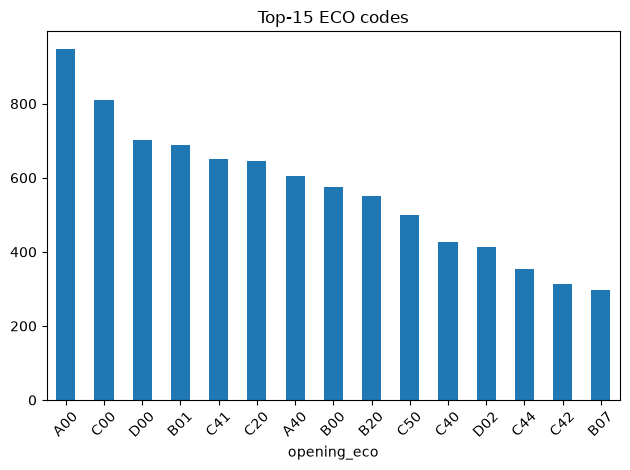

In [8]:
df['opening_eco'].value_counts().head(15).plot.bar(rot=45)
plt.title('Top-15 ECO codes'); plt.tight_layout(); plt.show()

## Feature–target relationships

**Task A:** the higher-rated side wins more often — `rating_diff` is the dominant (and nearly the only) pre-game signal.

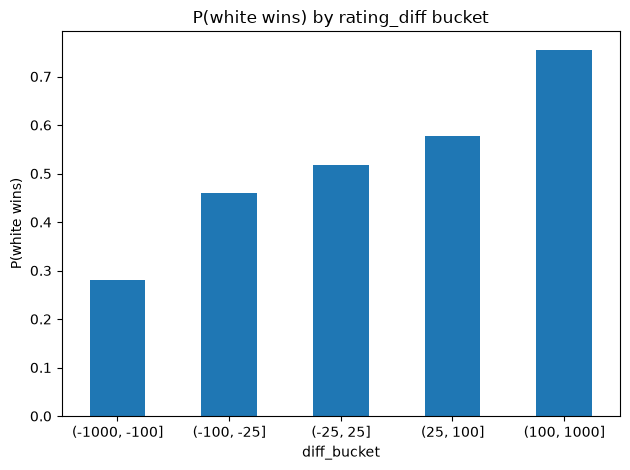

In [9]:
dec = eng[eng['winner'].isin(['white','black'])].copy()
dec['diff_bucket'] = pd.cut(dec['rating_diff'], [-1000,-100,-25,25,100,1000])
(dec.assign(white_win=dec['winner'].eq('white'))
    .groupby('diff_bucket', observed=True)['white_win'].mean()
    .plot.bar(rot=0, title='P(white wins) by rating_diff bucket'))
plt.ylabel('P(white wins)'); plt.tight_layout(); plt.show()

**Task B:** `opening_ply` (how long players stayed in book theory) and game length both rise with rating — these turn out to be the top regression features.

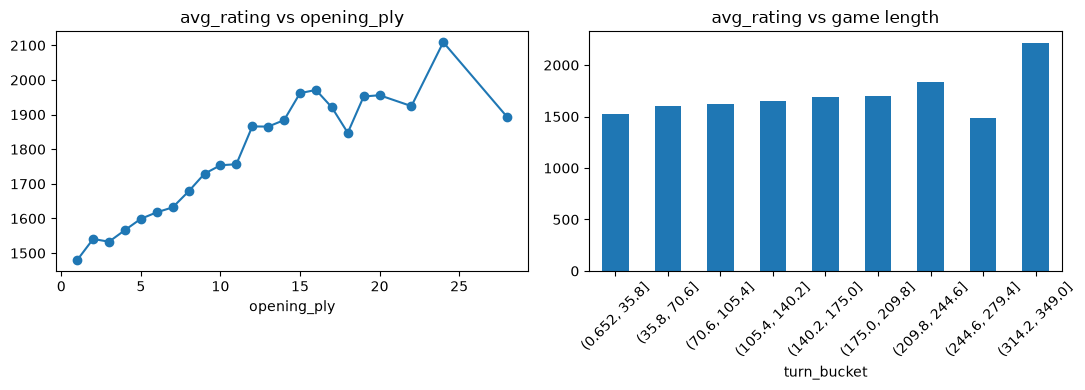

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
eng.groupby('opening_ply')['avg_rating'].mean().plot(ax=axes[0],
    title='avg_rating vs opening_ply', marker='o')
eng.assign(turn_bucket=pd.cut(eng['turns'], 10)).groupby(
    'turn_bucket', observed=True)['avg_rating'].mean().plot.bar(ax=axes[1],
    rot=45, title='avg_rating vs game length')
plt.tight_layout(); plt.show()

## The move-count leak (why Task A excludes `turns`)

The player who delivers mate / forces resignation makes the **last** move, so the *parity* of the move count nearly determines the winner. This is why `move_count` is excluded from Task A despite being available — including it inflates accuracy to ~0.83 via this artifact rather than real skill.

In [11]:
dec = df[df['winner'].isin(['white','black'])].copy()
dec['parity'] = np.where(dec['turns'] % 2 == 1, 'odd (white last)', 'even (black last)')
ct = pd.crosstab(dec['parity'], dec['winner'], normalize='index').round(3)
print(ct)
pred = np.where(dec['turns'] % 2 == 1, 'white', 'black')
print('\nparity-only accuracy on decisive games:', round((pred == dec['winner']).mean(), 3))

winner             black  white
parity                         
even (black last)  0.884  0.116
odd (white last)   0.093  0.907

parity-only accuracy on decisive games: 0.896


## Takeaways

1. **Task A is hard from pre-game features alone.** `rating_diff` is essentially the only signal; the model ends up close to a 'higher-rated wins' heuristic and rarely predicts the rare draw class.
2. **Task B is moderately learnable.** Opening depth, opening identity, game length and result-status carry real signal about player strength.
3. **Leakage is subtle.** Move-count parity nearly encodes the winner — a good reminder to scrutinise 'post-hoc' features, not just obviously-leaky ones.